# Day 13: The Central Limit Theorem

The main portions of theory that match probability with statistical hypothesis testing are the following:
- The Central Limit Theorem
- Law of Large Numbers

This notebook will go over the theory briefly but mainly show examples of how these two ideas work together.

In [1]:
from datascience import *
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np
import seaborn as sns
import scipy.stats as stats
from scipy.stats import gaussian_kde
from ipywidgets import interact, IntSlider

## Read in some CSV data files from the web.
united = Table.read_table('http://faculty.ung.edu/rsinn/data/united.csv')
sky = Table.read_table('http://faculty.ung.edu/rsinn/data/skyscrapers_v2.csv')
top_movies = Table.read_table('http://faculty.ung.edu/rsinn/data/top_movies_2017.csv')
pers = Table.read_table('http://faculty.ung.edu/rsinn/personality.csv')

## Sampling Distribution

For a fixed population and fixed sample size, and for a particular statistic (most often the mean), the collection of all possible values of that statistic over all possible samples of that size, forms what we call the sampling distribution.

The graphs below show a fixed population and (partial) sampling distributions for various sample sizes. 

### Uniform Population

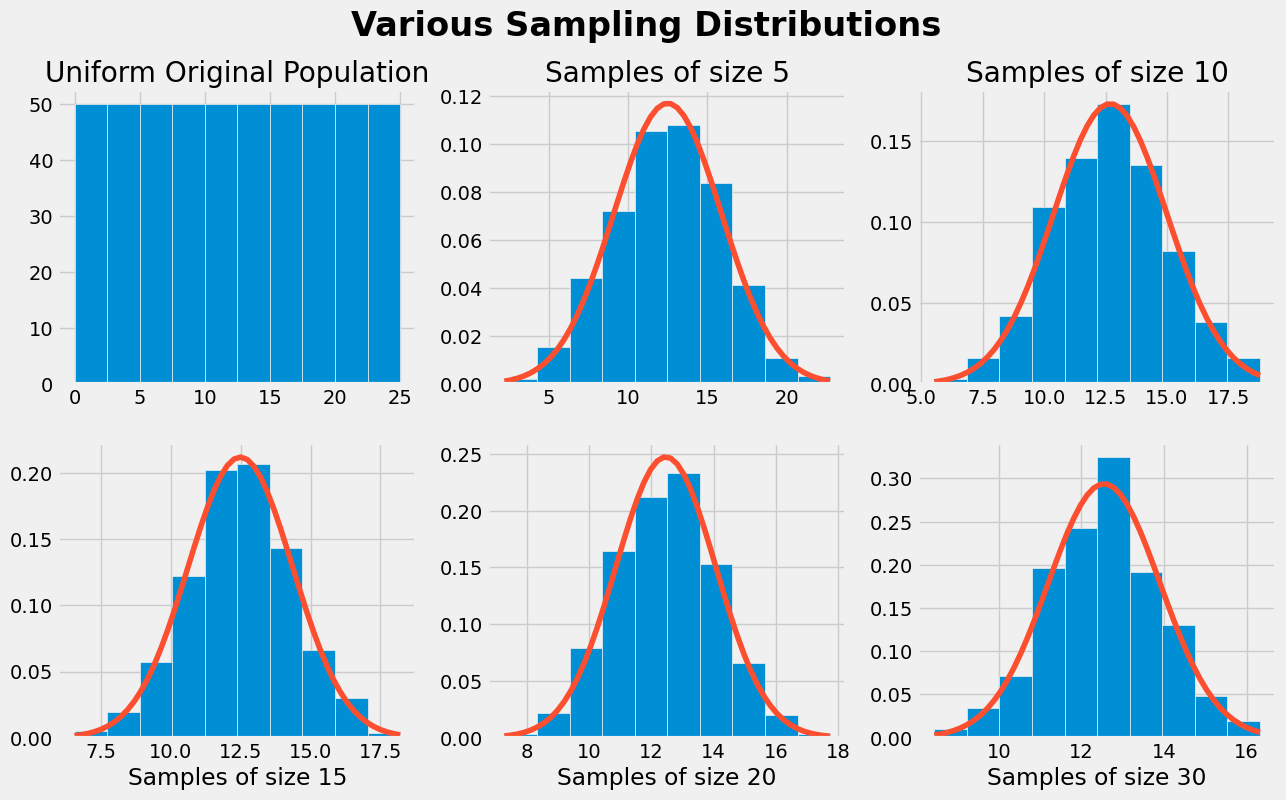

In [12]:
from hidden_demos import sampling_distribution_demo1
sampling_distribution_demo1()

### Symmetric but non-uniform population

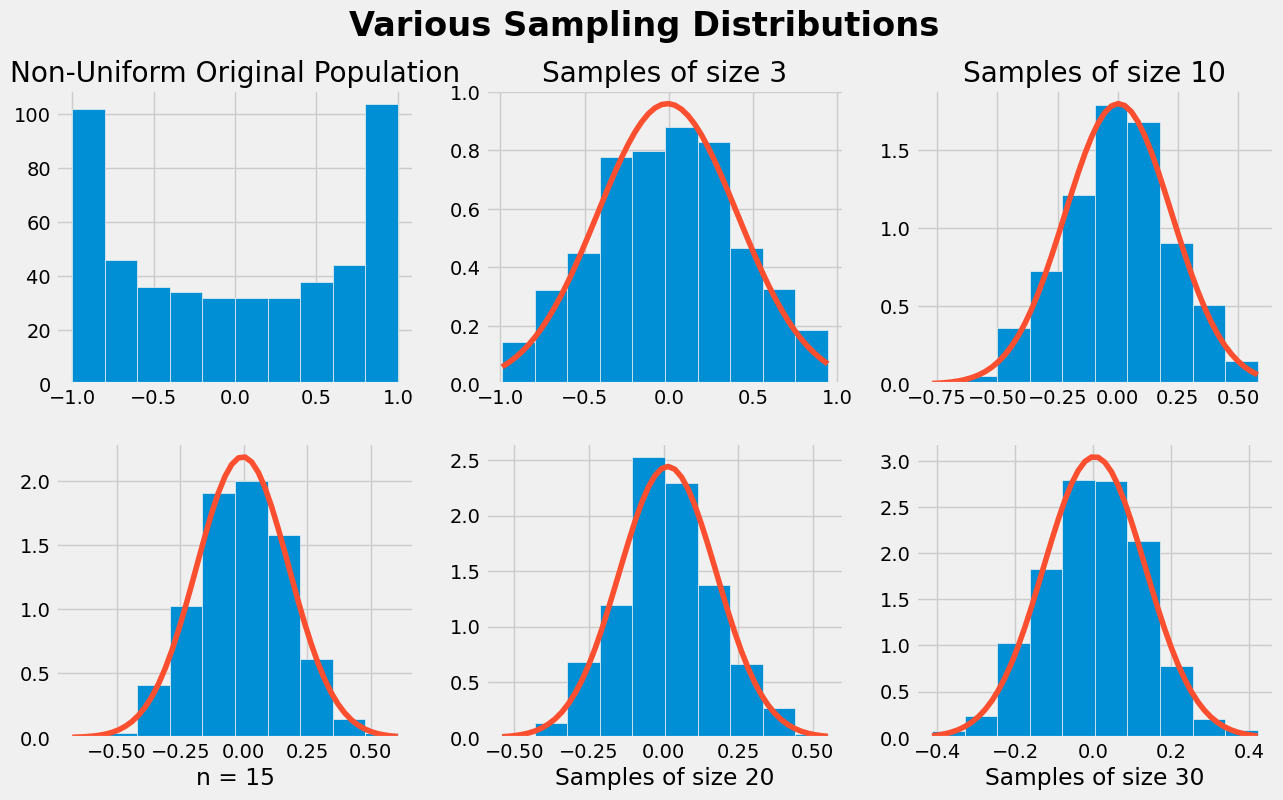

In [13]:
from hidden_demos import sampling_distribution_demo2
sampling_distribution_demo2()

## What were we supposed to observe in these graphs above? ##

1. As the sample size increased, all the sampling distributions began to approach normal distributions.  Did you notice the normal curve superimposed on most graphs?

2. For the example where the population was normal to start with, the sampling distribution *always* looked normal.

3. Did you notice that the scaling on the x-axis kept changing?  Go back and look again.

    As the sample size *increased* the spread along the x-axis *decreased*.  That's not just a coincidence or a trick.  The standard deviations are shrinking as the sample size increases, and there's even a formula that predicts what the sampling distributions standard deviation should be.  



### Law of Large Numbers ###

If $\overline{X}_n$ is the average of $n$ many $x_i$ all drawn from the same population/distribution with mean $\mu$ then as $n$ increases, $\overline{X}_n$ will approach $\mu$.  

That is, when your sample size is very large, you can have some confidence that the sample average is "pretty close" to the population average.  Later, when we study confidence intervals, we'll be able to quantify what counts as "pretty close".


### Central Limit Theorem ###

Assume $\overline{X}_n$ is the average of $n$ many $x_i$ all drawn from the same population/distribution with mean $\mu$ and population standard deviation $\sigma$.  Then $\overline{X}_n$ is a member of a sampling distribution.  For large values of $n$, this sampling distribution can be assumed approximately normal.  Specifically, the sampling distribution can be assumed to be $\displaystyle N\left(\mu, \frac{\sigma}{\sqrt{n}} \right)$.  

*Recall N(m, s) refers to a normal distribution with a mean of m and a standard deviation of s.*

What counts as a large sample size?  Generally, above 32 is considered large enough that most sampling distributions are at least approximately normal.  We saw with our Non-Symmetric Original Population example that sometimes it can take much larger samples before the graph appears normal; fortunately, such strongly skewed original populations don't come up often, and when they do, it's easy to detect.

## How this Works in Statistics

We can watch the same process of **sampling distributions** at work in a numeric variable by isolating a specifc **Data Table** and **Column Title**.

### Sampling Distributions from a Table and Column

We can focus the code below on a specific numeric variable to estimate by selecting:
- Table Name or **tab**
- Column Title or **col**

We will set the values
- sample_size
- num_simulations
to create an **animation** with a slider that allows us to increase **sample_size**. Focus on how increasing the **sample_size** changes the graphics shown.

We will be watching the **Central Limit Theorem** at work as sample size increases.

In [14]:
tab = united            ## Data table name.
col = 'Delay'           ## Column of table where variable of interest lives.
LoL_repetitions = 500   ## Keep value <= 2,500 or animation is painfully slow.

sample_size_min = 25
sample_size_max = 500
step_size = 20

## Sampling Function -- leave the code below as is!
def sample_mean(size):
    return np.average(tab.sample(size).column(col))

## Animating Code -- leave the code below as is!
@interact(sam_size=IntSlider(min=sample_size_min, max=sample_size_max, step=step_size, value=sample_size_min, description='Sample Size:'))
def plot_sample_means(sam_size):
    sample_means = make_array()
    for i in np.arange(LoL_repetitions):
        new_mean = sample_mean(sam_size)
        sample_means = np.append(sample_means, new_mean)
    print("Average of sample means:", np.average(sample_means))
    Table().with_column('Sample means', sample_means).hist()
    plots.title(f'Sampling Distribution of {col}')

interactive(children=(IntSlider(value=25, description='Sample Size:', max=500, min=25, step=20), Output()), _d…

## Example 2

For the table **sky**, let's create a sampling distribution using the column **height** by adjusting the code above.

In [ ]:
tab = ...                ## Data table name.
col = ...           ## Column of table where variable of interest lives.
LoL_repetitions = 100    ## Keep value <= 2,500 or animation is painfully slow.

sample_size_min = 2
sample_size_max = 50
step_size = 1

## Sampling Function -- leave the code below as is!
def sample_mean(size):
    return np.average(tab.sample(size).column(col))

## Animating Code -- leave the code below as is!
@interact(sam_size=IntSlider(min=sample_size_min, max=sample_size_max, step=step_size, value=sample_size_min, description='Sample Size:'))
def plot_sample_means(sam_size):
    sample_means = make_array()
    for i in np.arange(LoL_repetitions):
        new_mean = sample_mean(sam_size)
        sample_means = np.append(sample_means, new_mean)
    print("Average of sample means:", np.average(sample_means))
    Table().with_column('Sample means', sample_means).hist()
    plots.title(f'Sampling Distribution of {col}')

## Example 3

For the table **sky**, let's create a sampling distribution using the column **height** by adjusting the code above.

In [ ]:
tab = ...                ## Data table name.
col = ...           ## Column of table where variable of interest lives.
LoL_repetitions = 150    ## Keep value <= 2,500 or animation is painfully slow.

sample_size_min = 20
sample_size_max = 100
step_size = 5

## Sampling Function -- leave the code below as is!
def sample_mean(size):
    return np.average(tab.sample(size).column(col))

## Animating Code -- leave the code below as is!
@interact(sam_size=IntSlider(min=sample_size_min, max=sample_size_max, step=step_size, value=sample_size_min, description='Sample Size:'))
def plot_sample_means(sam_size):
    sample_means = make_array()
    for i in np.arange(LoL_repetitions):
        new_mean = sample_mean(sam_size)
        sample_means = np.append(sample_means, new_mean)
    print("Average of sample means:", np.average(sample_means))
    Table().with_column('Sample means', sample_means).hist()
    plots.title(f'Sampling Distribution of {col}')

## Example 4: Dice Rolls

In the code below, change only the values:
- sample_size
- num_simulations

Focus on changing **sample_size** first, increasing it in stages and rerunning the code.

We will be watching the **Central Limit Theorem** at work as sample size increases along with the **Law of Large Numbers** as number of simulations increases.

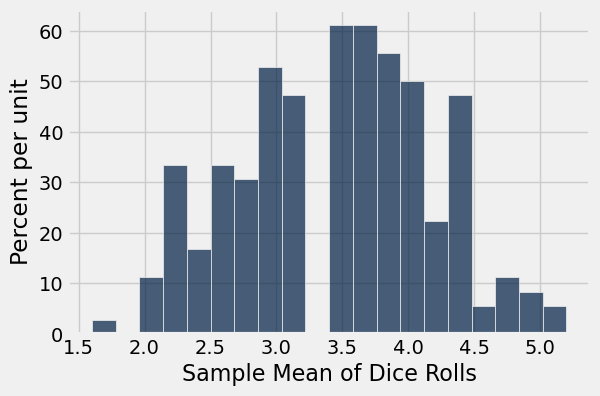

In [24]:
die_dist = stats.randint(1, 7)  # Discrete uniform distribution [1, 2, 3, 4, 5, 6]

sample_size = 5          ## Number of dice rolled per sample
num_simulations = 200


sample_means = make_array()
for i in np.arange(num_simulations):
    simulated_rolls = die_dist.rvs(size=sample_size)
    sim_mean = np.mean(simulated_rolls)
    sample_means = np.append(sample_means, sim_mean)

dice_sampling_dist = Table().with_column('Sample Mean of Dice Rolls', sample_means)
dice_sampling_dist.hist(bins=20)

## Example 5: Coin Flips

In the code below, change only the values:
- sample_size
- num_simulations

Focus on changing **sample_size** first, increasing it in stages and rerunning the code.

We will be watching the **Central Limit Theorem** at work as sample size increases along with the **Law of Large Numbers** as number of simulations increases.

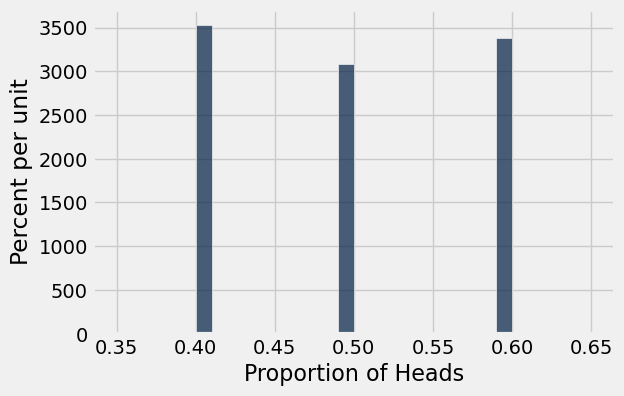

In [25]:
coin = Table().with_columns('Outcome', make_array('Heads', 'Tails'))

num_simulations = 200
sample_size = 10          ## Number of coin flips per sample

proportions_heads = make_array()
for i in np.arange(num_simulations):
    simulated_sample = coin.sample(sample_size)
    num_heads = simulated_sample.where('Outcome', are.equal_to('Heads')).num_rows
    prop_heads = num_heads / sample_size
    proportions_heads = np.append(proportions_heads, prop_heads)

sampling_distribution = Table().with_column('Proportion of Heads', proportions_heads)
sampling_distribution.hist(bins=np.arange(0.35, 0.65, 0.01))